# Perform single-cell quality control

In this notebook, we perform single-cell quality control using coSMicQC. We filter the single cells by identifying outliers with z-scores, and use either combinations of features or one feature for each condition. 

In [1]:
import os
import pathlib
import re
import json

import matplotlib

matplotlib.use("Agg")  # Ensures no GUI windows are opened
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cytodataframe import CytoDataFrame
from cosmicqc import find_outliers

## Set paths and variables

In [2]:
# Optional: set `BATCH` and `PLATEMAP_LAYOUT` env vars to process a specific batch and platemap
batch_to_process = os.environ.get("BATCH", "batch_3")
print(f"Processing batch: {batch_to_process}")

# Set base directory for where the SQLite files are located (should be local to repo)
base_dir = pathlib.Path(
    f"../../2.cellprofiler_processing/cp_output/{batch_to_process}"
).resolve(strict=True)

Processing batch: batch_3


In [3]:
# Parameters
platemap_layout = "platemap_9"
plate_id = "CARD-CelIns-CX7_260108130001"

In [4]:
# Directory with data
data_dir = pathlib.Path(
    f"../data/{batch_to_process}/{platemap_layout}/converted_profiles/"
).resolve(strict=True)

# Path to main JSON file
thresholds_json_path = pathlib.Path("../sc_qc_thresholds.json")

# Load existing thresholds from json file if it exists, otherwise start with empty dictionary
if thresholds_json_path.exists():
    with open(thresholds_json_path, "r") as f:
        qc_thresholds_dict = json.load(f)
        print(f"Loaded existing thresholds from {thresholds_json_path}")
else:
    qc_thresholds_dict = {}
    print(
        f"No existing thresholds file found at {thresholds_json_path}, starting with empty dictionary."
    )

# Set the layout and plate keys in the dictionary
layout_dict = qc_thresholds_dict.setdefault(platemap_layout, {})
plate_dict = layout_dict.setdefault(plate_id, {})

# Metadata columns to include in output data frame (based on compartment)
nuclei_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_PathName_DNA",
    "Image_FileName_DNA",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
]
cells_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Cells_Location_Center_X",
    "Metadata_Cells_Location_Center_Y",
    "Image_PathName_DNA",
    "Image_FileName_DNA",
    "Image_PathName_Actin",
    "Image_FileName_Actin",
    "Cells_AreaShape_BoundingBoxMaximum_X",
    "Cells_AreaShape_BoundingBoxMaximum_Y",
    "Cells_AreaShape_BoundingBoxMinimum_X",
    "Cells_AreaShape_BoundingBoxMinimum_Y",
]

Loaded existing thresholds from ../sc_qc_thresholds.json


## Load in plate to perform QC on

In [5]:
# Set plate path
plate_path = pathlib.Path(f"{data_dir}/{plate_id}_converted.parquet").resolve(
    strict=True
)

# Load the converted plate data
plate_df = pd.read_parquet(plate_path)

# Print the shape of the DataFrame for each plate
print(f"Loaded plate: {plate_path.stem}, Shape: {plate_df.shape}")

Loaded plate: CARD-CelIns-CX7_260108130001_converted, Shape: (5253, 2476)


## Correct pathing to local to find images

In [6]:
# Fix image paths to point to corrected images
correct_parent = "/home/jenna"

for col in plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        plate_df[col] = plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*jtomkinson@xsede.org/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )
        # Update the folder name from 1.illumination_correction to 1b.illumination_correction
        plate_df[col] = plate_df[col].str.replace(
            "1.illumination_correction", "1b.illumination_correction"
        )

# Print example image path after fix
print(plate_df["Image_PathName_DNA"].dropna().iloc[0])

/home/jenna/targeted_fibrosis_drug_screen/1b.illumination_correction/Corrected_Images/batch_3/platemap_9/CARD-CelIns-CX7_260108130001


In [7]:
# Print example image file
print(plate_df["Image_FileName_DNA"].dropna().iloc[0])

CARD-CelIns-CX7_260108130001_B02f12d4_illumcorrect.tiff


## Set mapping for outlines

In [8]:
# Define available compartments
compartments = ["Nuclei", "Cells"]

# Create a dictionary of mappings for each compartment
mapping_dict = {
    comp: {
        rf"{comp}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": rf"{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}{record['Image_Metadata_Site']}.*\.tiff"
        for record in plate_df[
            ["Image_Metadata_Plate", "Image_Metadata_Well", "Image_Metadata_Site"]
        ].to_dict(orient="records")
    }
    for comp in compartments
}

## Detect over-segmented nuclei using shape and intensity

In [9]:
# Set mapping for Nuclei compartment
outline_to_orig_mapping = mapping_dict["Nuclei"]

Number of outliers: 103 (1.96%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.5936896329684481
Nuclei_AreaShape_Solidity Max: 0.9531422271223815
Nuclei_Intensity_MassDisplacement_DNA Min: 1.9652632034001847
Nuclei_Intensity_MassDisplacement_DNA Max: 26.23551960362353
(103, 5)


,1749,508,4791,3648,4810
Image_Metadata_Well,C08,F11,E04,E04,B09
Image_Metadata_Site,f24,f24,f10,f08,f01
Nuclei_AreaShape_Solidity,0.894853,0.753994,0.848074,0.886888,0.840588
Nuclei_Intensity_MassDisplacement_DNA,5.369377,2.184191,2.115703,2.726581,2.726122
Image_FileName_DNA,,,,,

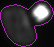
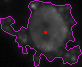
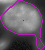
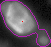
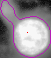

In [10]:
feature_thresholds_oversegmented_nuclei = {
    "Nuclei_AreaShape_Solidity": -0.5,
    "Nuclei_Intensity_MassDisplacement_DNA": 1.6,
}

# Save thresholds to dictionary for current condition
plate_dict["oversegmented_nuclei"] = feature_thresholds_oversegmented_nuclei

# Find large nuclei outliers for the current plate
oversegmented_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=feature_thresholds_oversegmented_nuclei,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
oversegmented_nuclei_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(oversegmented_nuclei_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 10,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Nuclei_AreaShape_Solidity",
        "Nuclei_Intensity_MassDisplacement_DNA",
        "Image_FileName_DNA",
    ]
]

if not oversegmented_nuclei_outliers_cdf.empty:
    print(oversegmented_nuclei_outliers_cdf.shape)
    # display(
    #     oversegmented_nuclei_outliers_cdf.sort_values(
    #         by="Nuclei_AreaShape_Solidity", ascending=False
    #     )
    #     .head(5)
    #     .T
    # )
    display(oversegmented_nuclei_outliers_cdf.sample(n=5).T)
else:
    print("No oversegmented nuclei outliers detected.")

## Detect mis-segmented background as nuclei

Number of outliers: 43 (0.82%)
Outliers Range:
Nuclei_Intensity_MeanIntensity_DNA Min: 0.0006087453630687384
Nuclei_Intensity_MeanIntensity_DNA Max: 0.01864791698126903


,3071,2435,1777,3304,3225
Image_Metadata_Well,B03,B11,E04,C03,C02
Image_Metadata_Site,f16,f04,f11,f06,f17
Nuclei_Intensity_MeanIntensity_DNA,0.018648,0.018171,0.0165,0.015557,0.014867
Image_FileName_DNA,,,,,

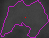
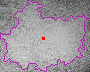
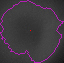
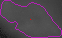
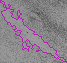

In [11]:
# Set feature thresholds for low total intensity
feature_thresholds_low_intensity = {
    "Nuclei_Intensity_MeanIntensity_DNA": -1.7,
}

# Save thresholds to dictionary for current condition
plate_dict["low_intensity_nuclei"] = feature_thresholds_low_intensity

# Find low intensity nuclei outliers for the current plate
low_intensity_outliers = find_outliers(
    df=plate_df,
    metadata_columns=nuclei_metadata_columns,
    feature_thresholds=feature_thresholds_low_intensity,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
low_intensity_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(low_intensity_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 10,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Nuclei_Intensity_MeanIntensity_DNA",
        "Image_FileName_DNA",
    ]
]

if not low_intensity_outliers_cdf.empty:
    display(
        low_intensity_outliers_cdf.sort_values(
            by="Nuclei_Intensity_MeanIntensity_DNA", ascending=False
        )
        .head(5)
        .T
    )
    # display(low_intensity_outliers_cdf.sample(n=5, random_state=0).T)
else:
    print("No low intensity nuclei outliers detected.")

## Detect under-segmented cells

In [12]:
# Set mapping for Cells compartment
outline_to_orig_mapping = mapping_dict["Cells"]

Number of outliers: 73 (1.39%)
Outliers Range:
Cells_AreaShape_Area Min: 719.0
Cells_AreaShape_Area Max: 3714.0
(73, 5)


,5249,47,1622,2933,869
Image_Metadata_Well,C05,D08,F03,B05,F03
Image_Metadata_Site,f03,f22,f15,f04,f15
Cells_AreaShape_Area,3714.0,3714.0,3685.0,3669.0,3644.0
Image_FileName_Actin,,,,,
Image_FileName_DNA,,,,,

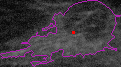
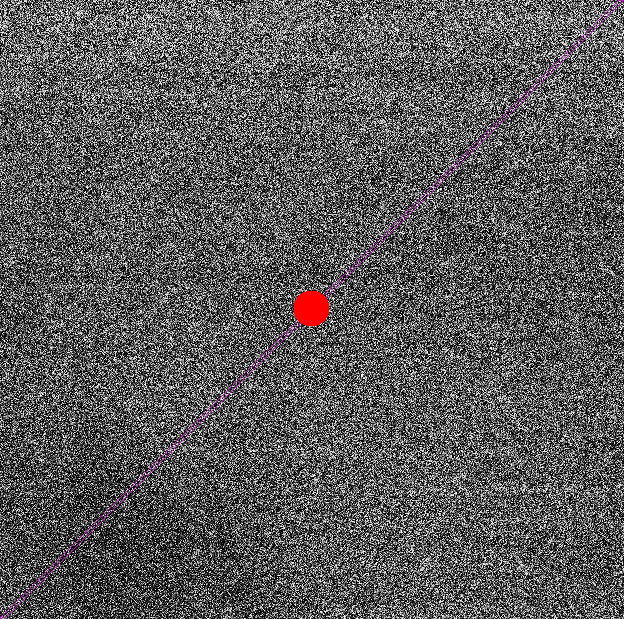
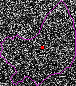
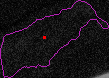
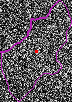
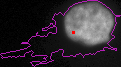
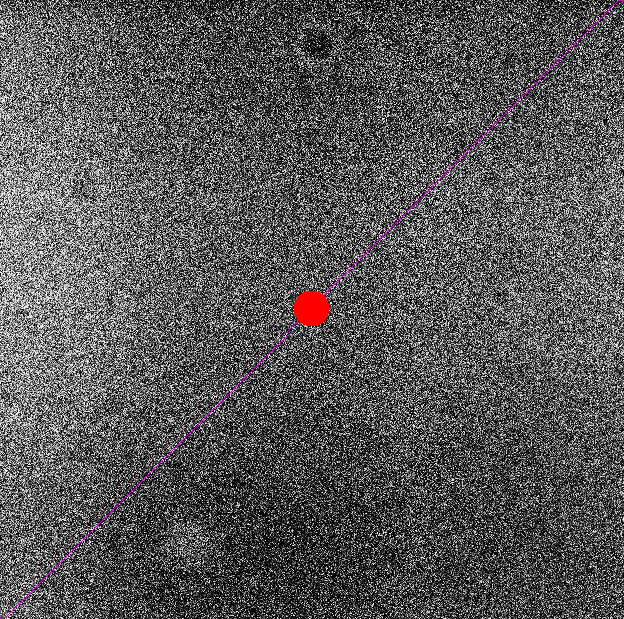
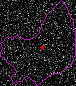
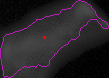
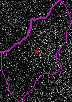

In [13]:
# Set feature thresholds for small cells
feature_thresholds_small_cells = {
    "Cells_AreaShape_Area": -1.45,
}

# Save thresholds to dictionary for current condition
plate_dict["undersegmented_cells"] = feature_thresholds_small_cells

# Find under-segmented cells outliers for the current plate
small_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=feature_thresholds_small_cells,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
small_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(small_cells_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 1,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Cells_AreaShape_Area",
        "Image_FileName_Actin",
        "Image_FileName_DNA",
    ]
]

if not small_cells_outliers_cdf.empty:
    print(small_cells_outliers_cdf.shape)
    display(
        small_cells_outliers_cdf.sort_values(by="Cells_AreaShape_Area", ascending=False)
        .head(5)
        .T
    )
else:
    print("No small cells outliers detected.")

## Detect blurry/out-of-focus cells

Number of outliers: 553 (10.53%)
Outliers Range:
Cells_Granularity_1_Actin Min: -0.3184156319132997
Cells_Granularity_1_Actin Max: 10.661267476097452
(553, 7)


,4039,3078,5075,873,2356
Image_Metadata_Plate,CARD-CelIns-CX7_260108130001,CARD-CelIns-CX7_260108130001,CARD-CelIns-CX7_260108130001,CARD-CelIns-CX7_260108130001,CARD-CelIns-CX7_260108130001
Image_Metadata_Well,C05,B03,G03,F07,G02
Image_Metadata_Site,f07,f24,f06,f03,f02
Cells_Granularity_1_Actin,10.661267,10.649801,10.649569,10.644069,10.63646
Image_FileName_Actin,,,,,
Metadata_Cells_Location_Center_X,354.448491,848.147578,260.412898,831.086923,865.915846
Metadata_Cells_Location_Center_Y,530.062873,665.172945,842.744714,427.983435,349.032939

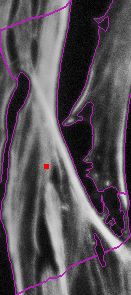
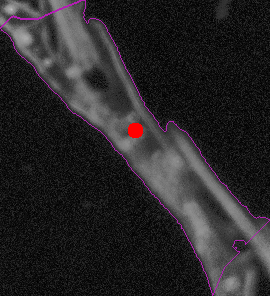
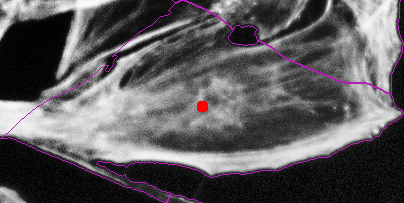
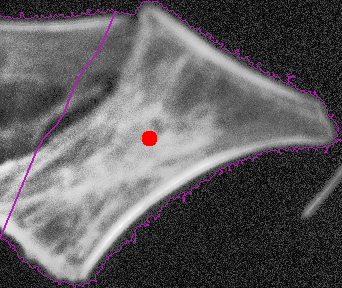
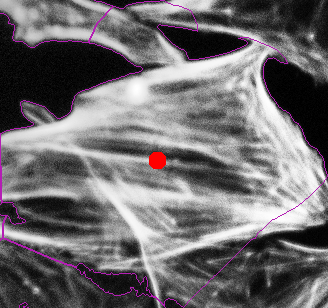

In [14]:
# find blurry cells
feature_thresholds_blurry_cells = {"Cells_Granularity_1_Actin": -1.05}

# Save thresholds to dictionary for current condition
plate_dict["blurry_cells"] = feature_thresholds_blurry_cells

blurry_cells_outliers = find_outliers(
    df=plate_df,
    metadata_columns=cells_metadata_columns,
    feature_thresholds=feature_thresholds_blurry_cells,
)

# MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
blurry_cells_outliers_cdf = CytoDataFrame(
    data=pd.DataFrame(blurry_cells_outliers),
    data_outline_context_dir=f"../../2.cellprofiler_processing/cp_output/{batch_to_process}/{platemap_layout}/{plate_id}",
    segmentation_file_regex=outline_to_orig_mapping,
    display_options={
        "center_dot": True,
        "brightness": 1,
        "outline_color": (180, 30, 180),
    },
)[
    [
        "Image_Metadata_Plate",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Cells_Granularity_1_Actin",
        "Image_FileName_Actin",
        "Metadata_Cells_Location_Center_X",
        "Metadata_Cells_Location_Center_Y",
    ]
]

if not blurry_cells_outliers_cdf.empty:
    print(blurry_cells_outliers_cdf.shape)
    display(
        blurry_cells_outliers_cdf.sort_values(
            by="Cells_Granularity_1_Actin", ascending=False
        )
        .head(5)
        .T
    )
else:
    print("No blurry cells outliers detected.")

## Take the dictionary and save to main JSON file

In [15]:
# Save the thresholds dictionary to a json file for use in main QC notebook
with open(thresholds_json_path, "w") as f:
    json.dump(qc_thresholds_dict, f, indent=4)
    print(
        f"Saved thresholds to {thresholds_json_path} for layout {platemap_layout} and plate {plate_id}"
    )

Saved thresholds to ../sc_qc_thresholds.json for layout platemap_9 and plate CARD-CelIns-CX7_260108130001
